In [ ]:
#Descriptive Analytics and Data Preprocessing on Sales & Discounts Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/sales_data_with_discounts.csv')
df

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770
...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,15-04-2021,Thursday,L06,C,2,Lifestyle,Jeera,M-Casuals,1300,2600,15.475687,402.367873,2197.632127
446,15-04-2021,Thursday,L07,C,6,Lifestyle,Viva,W-Western,2600,15600,17.057027,2660.896242,12939.103758
447,15-04-2021,Thursday,L08,C,2,Lifestyle,Viva,W-Lounge,1600,3200,18.965550,606.897606,2593.102394
448,15-04-2021,Thursday,L09,C,3,Lifestyle,Jeera,M-Formals,1900,5700,16.793014,957.201826,4742.798174


In [ ]:
df.head()

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770


In [ ]:
df.shape

(450, 13)

In [ ]:
df.size

5850

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               450 non-null    object 
 1   Day                450 non-null    object 
 2   SKU                450 non-null    object 
 3   City               450 non-null    object 
 4   Volume             450 non-null    int64  
 5   BU                 450 non-null    object 
 6   Brand              450 non-null    object 
 7   Model              450 non-null    object 
 8   Avg Price          450 non-null    int64  
 9   Total Sales Value  450 non-null    int64  
 10  Discount Rate (%)  450 non-null    float64
 11  Discount Amount    450 non-null    float64
 12  Net Sales Value    450 non-null    float64
dtypes: float64(3), int64(3), object(7)
memory usage: 45.8+ KB


In [ ]:
df.isnull().sum()

,0
Date,0
Day,0
SKU,0
City,0
Volume,0
BU,0
Brand,0
Model,0
Avg Price,0
Total Sales Value,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.dtypes

,0
Date,object
Day,object
SKU,object
City,object
Volume,int64
BU,object
Brand,object
Model,object
Avg Price,int64
Total Sales Value,int64


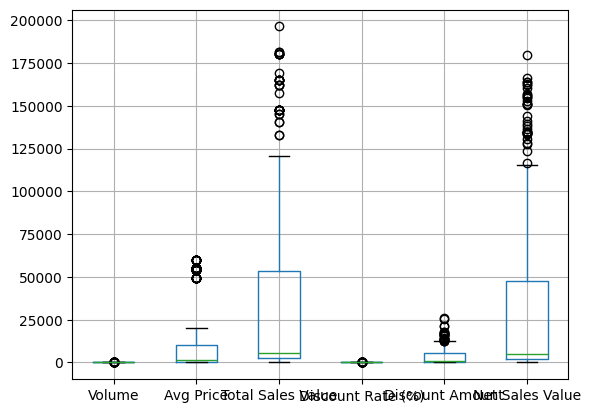

In [ ]:
#checking outliers
df.boxplot()
plt.show()

In [ ]:
# Identify numerical columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

In [ ]:
# Mean
print("\nMean")
print(df[numerical_columns].mean())

# Median
print("\nMedian")
print(df[numerical_columns].median())

# Mode
print("\nMode")
print(df[numerical_columns].mode())

# Standard Deviation
print("\nStandard Deviation")
print(df[numerical_columns].std())




Mean
Volume                   5.066667
Avg Price            10453.433333
Total Sales Value    33812.835556
Discount Rate (%)       15.155242
Discount Amount       3346.499424
Net Sales Value      30466.336131
dtype: float64

Median
Volume                  4.000000
Avg Price            1450.000000
Total Sales Value    5700.000000
Discount Rate (%)      16.577766
Discount Amount       988.933733
Net Sales Value      4677.788059
dtype: float64

Mode
     Volume  Avg Price  Total Sales Value  Discount Rate (%)  Discount Amount  \
0       3.0      400.0            24300.0           5.007822        69.177942   
1       NaN      450.0                NaN           5.055218        73.025199   
2       NaN      500.0                NaN           5.059801        93.649161   
3       NaN     1300.0                NaN           5.072124        94.682735   
4       NaN     8100.0                NaN           5.084108       102.705757   
..      ...        ...                ...                ...  

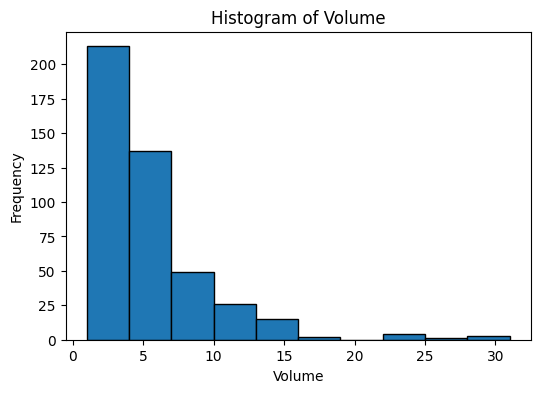

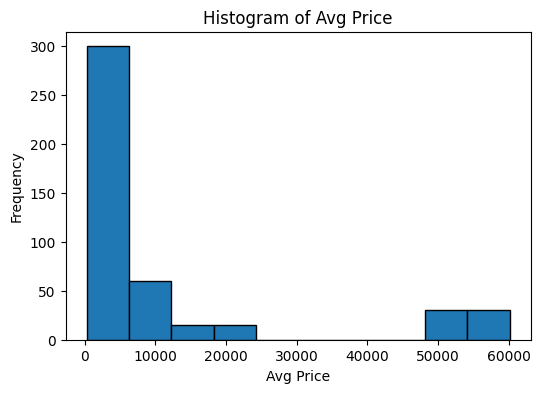

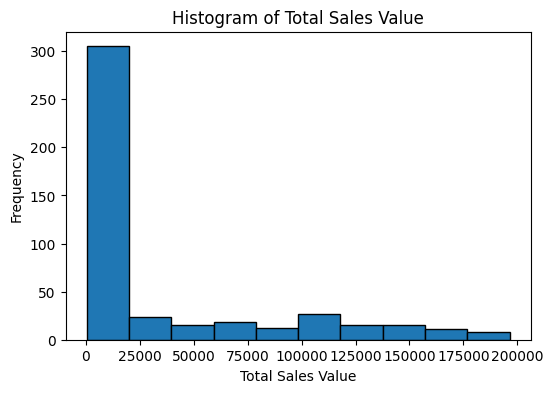

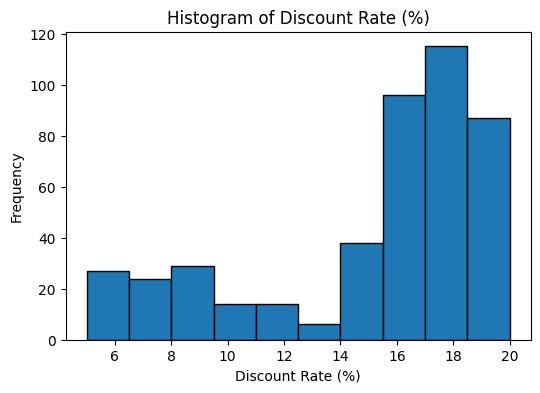

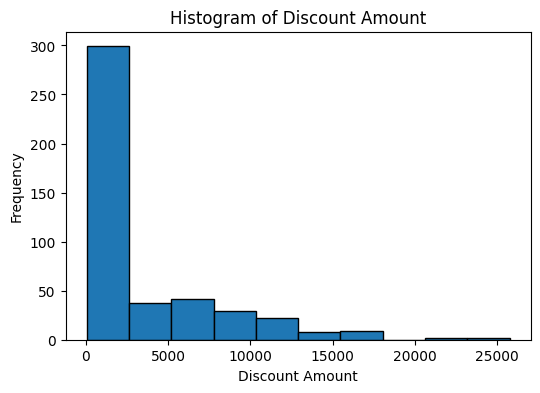

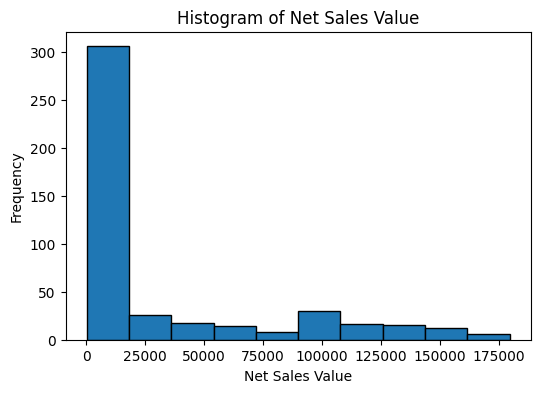

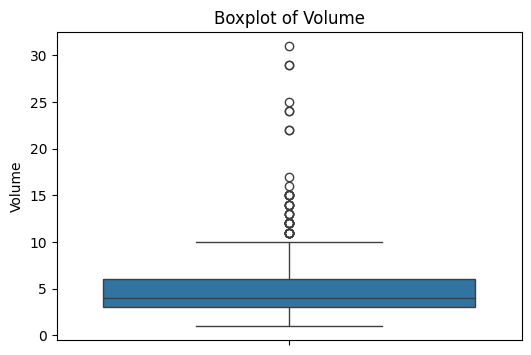

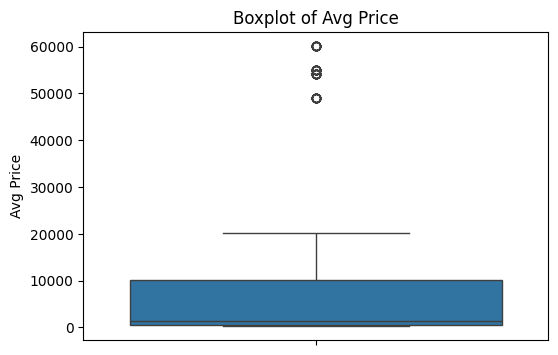

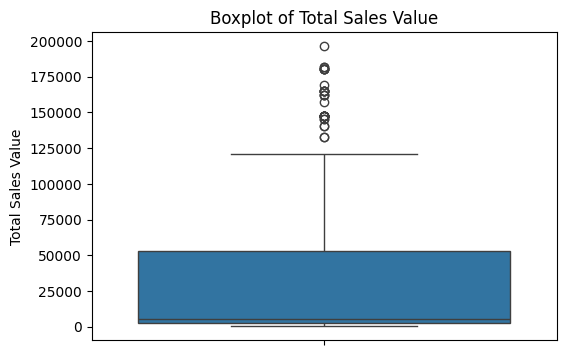

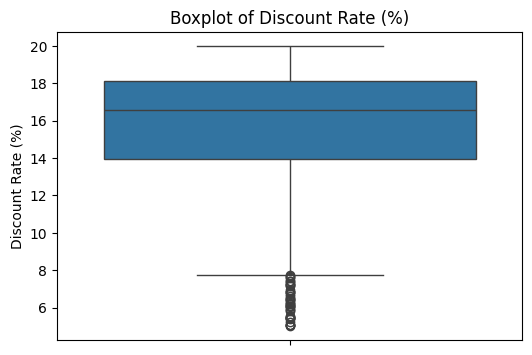

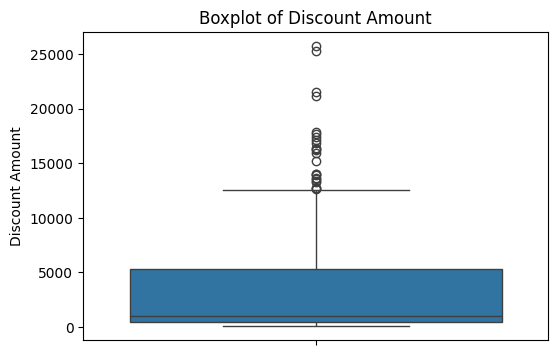

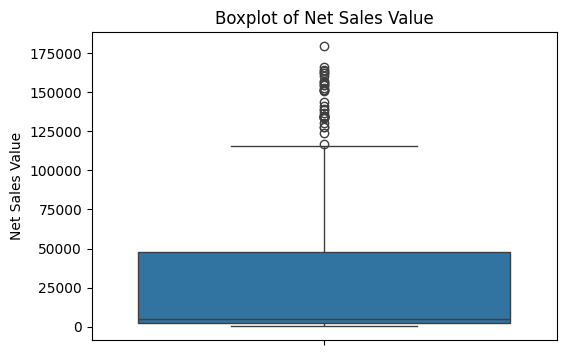

In [ ]:
# Histograms


for column in numerical_columns:
    plt.figure(figsize=(6,4))
    plt.hist(df[column], bins=10, edgecolor='black')
    plt.title("Histogram of " + column)
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

# --------------------------------------------------
# Boxplots
# --------------------------------------------------

for column in numerical_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=df[column])
    plt.title("Boxplot of " + column)
    plt.ylabel(column)
    plt.show()

In [ ]:
# Bar Charts for Categorical Columns
categorical_columns = df.select_dtypes(include=['object']).columns

Index(['Date', 'Day', 'SKU', 'City', 'BU', 'Brand', 'Model'], dtype='object')


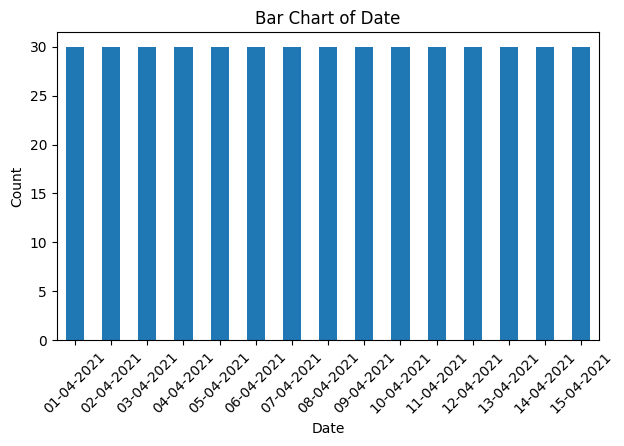

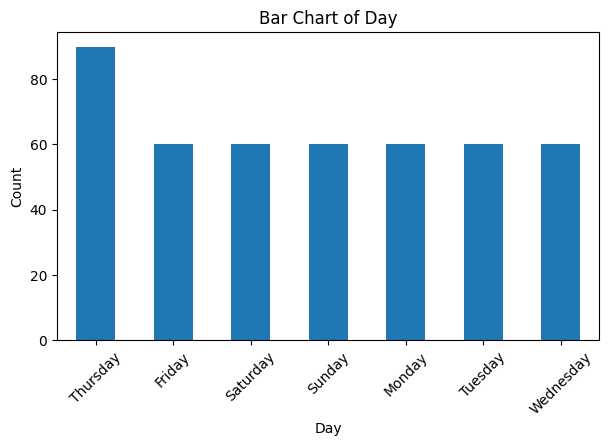

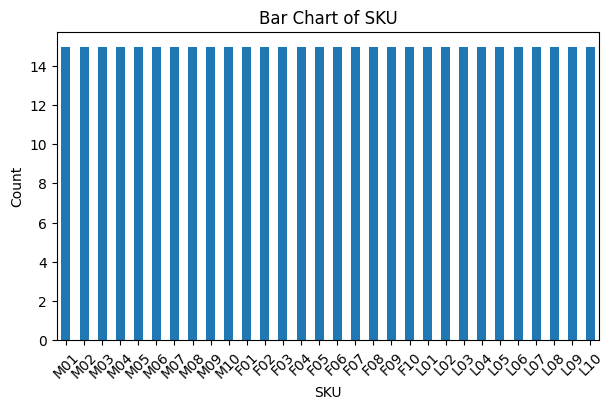

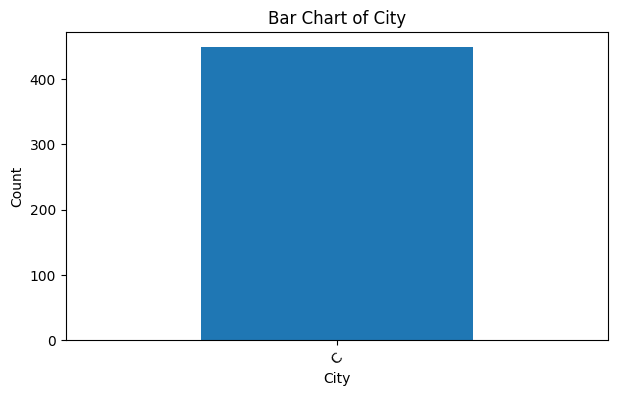

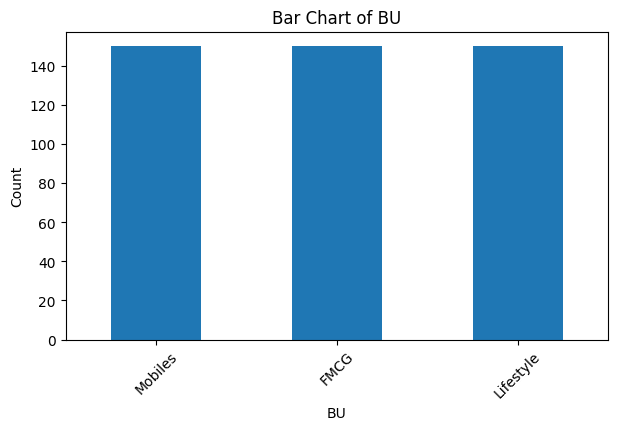

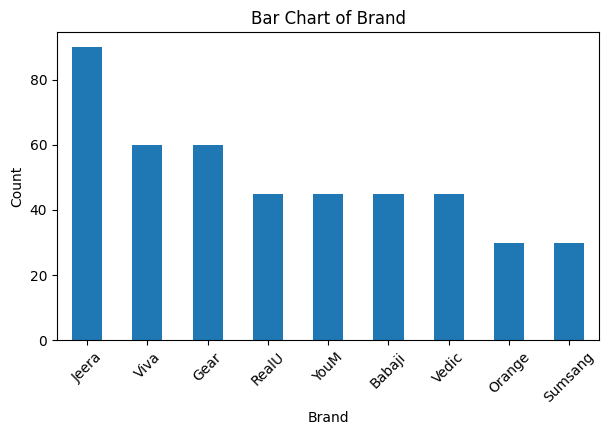

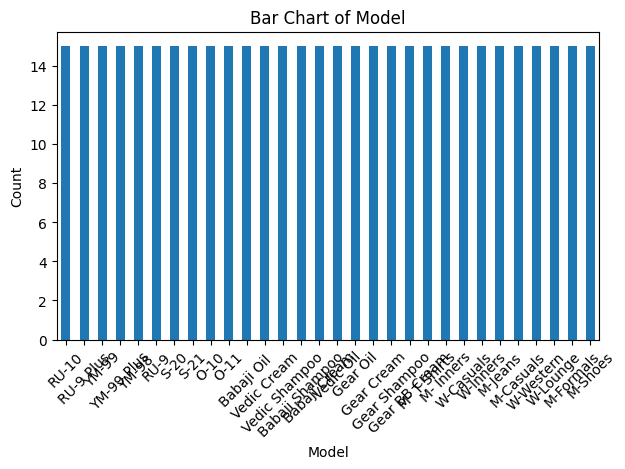

In [22]:
print(categorical_columns)

for column in categorical_columns:
    plt.figure(figsize=(7,4))
    df[column].value_counts().plot(kind='bar')
    plt.title("Bar Chart of " + column)
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()


In [24]:
# Data Preprocessing

# Missing Values
print("\nMissing Values")
print(df.isnull().sum())

# Duplicate Records
print("\nDuplicate Records")
print(df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates()

# Check data types
print("\nData Types")
print(df.dtypes)



Missing Values
Date                 0
Day                  0
SKU                  0
City                 0
Volume               0
BU                   0
Brand                0
Model                0
Avg Price            0
Total Sales Value    0
Discount Rate (%)    0
Discount Amount      0
Net Sales Value      0
dtype: int64

Duplicate Records
0

Data Types
Date                  object
Day                   object
SKU                   object
City                  object
Volume                 int64
BU                    object
Brand                 object
Model                 object
Avg Price              int64
Total Sales Value      int64
Discount Rate (%)    float64
Discount Amount      float64
Net Sales Value      float64
dtype: object


In [29]:
# Conclusion
print("\nConclusion")
print("The descriptive statistics provide an overview of the numerical data.")
print("Histograms show the distribution of values.")
print("Boxplots identify outliers.")
print("Bar charts display the frequency of categorical variables.")
print("The dataset has been checked for missing values and duplicate records,")
print("making it ready for further analysis.")



Conclusion
The descriptive statistics provide an overview of the numerical data.
Histograms show the distribution of values.
Boxplots identify outliers.
Bar charts display the frequency of categorical variables.
The dataset has been checked for missing values and duplicate records,
making it ready for further analysis.
